In [1]:
# Использование Tensorflow

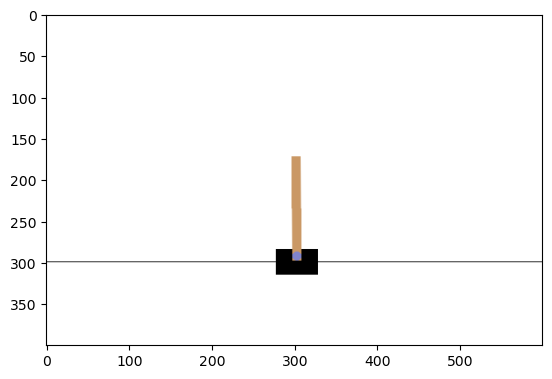

In [2]:
import sys, os
# Этот код создает виртуальный дисплей для рисования игровых изображений.
# Это не будет иметь никакого эффекта, если на вашей машине есть монитор.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape

plt.imshow(env.render())
plt.show()

In [ ]:
import tensorflow as tf
import keras
import keras.layers as L

tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()
sess = tf.compat.v1.InteractiveSession()
tf.compat.v1.keras.backend.set_session(sess)

assert not tf.config.list_physical_devices('GPU'), \
 "Пожалуйста, выполните это задание без графического процессора. Если вы используете графический процессор, код " \
 "будет работать намного медленнее из-за большого количества операций копирования в память графического процессора и из нее." \
 "Чтобы отключить графический процессор в Colab, выберите «Runtime» → «Change runtime type» → «None»."

In [ ]:
# Создание сети для приблизительного Q-обучения
network = keras.models.Sequential()
network.add(L.InputLayer(state_dim))

# Ваш код: создайте сеть для приблизительного q-обучения
network.add(L.Dense(128, activation='relu'))  # Скрытый слой с 128 нейронами
network.add(L.Dense(64, activation='relu'))   # Второй скрытый слой с 64 нейронами
network.add(L.Dense(n_actions, activation='linear'))  # Выходной слой с Q-значениями

network.summary()

In [5]:
def get_action(state, epsilon=0):
    """
    Выбор действия с эпсилон-жадной политикой
    С вероятностью p=epsilon выбрать случайное действие,
    иначе выбрать действие с наибольшим Q(s, a)
    """
    q_values = network.predict(state[None])[0]
    
    # Ваш код: эпсилон-жадно выбранное действие
    if np.random.random() < epsilon:
        action = np.random.randint(0, n_actions)
    else:
        action = np.argmax(q_values)
    
    return action

In [19]:
# Проверка архитектуры сети
assert network.output_shape == (None, n_actions), \
    "пожалуйста, убедитесь, что ваша модель отображает состояние s->[Q(s,a0),..., Q(s, a_last)]"

assert network.layers[-1].activation == keras.activations.linear, \
    "пожалуйста, убедитесь, что вы предсказываете q-значения без нелинейности"

# Проверка эпсилон-жадных исследований
s = env.reset()[0] if isinstance(env.reset(), tuple) else env.reset()
assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [7]:
# Q-обучение через градиентный спуск

In [8]:
# Создание плейсхолдеров для <s, a, r, s'> кортежа и специального индикатора окончания игры
states_ph = tf.compat.v1.keras.backend.placeholder(dtype='float32', shape=(None,) + state_dim)
actions_ph = tf.compat.v1.keras.backend.placeholder(dtype='int32', shape=[None])
rewards_ph = tf.compat.v1.keras.backend.placeholder(dtype='float32', shape=[None])
next_states_ph = tf.compat.v1.keras.backend.placeholder(dtype='float32', shape=(None,) + state_dim)
is_done_ph = tf.compat.v1.keras.backend.placeholder(dtype='bool', shape=[None])

# Задание Q-значений для всех действий в текущем состоянии
predicted_qvalues = network(states_ph)

# Выборка Q-значений для выбранных действий
predicted_qvalues_for_actions = tf.reduce_sum(
    predicted_qvalues * tf.one_hot(actions_ph, n_actions), 
    axis=1
)

In [9]:
gamma = 0.99

# Ваш код: применить ИНС для получения q-значений для next_states_ph
predicted_next_qvalues = network(next_states_ph)

# Ваш код: максимум по действиям
next_state_values = tf.reduce_max(predicted_next_qvalues, axis=1)

# Ваш код: формула Bellman
target_qvalues_for_actions = rewards_ph + gamma * next_state_values

# В последнем состоянии будем использовать упрощенную формулу: Q(s,a) = r(s,a), так как s' не существует
target_qvalues_for_actions = tf.where(is_done_ph, rewards_ph, target_qvalues_for_actions)

In [20]:
# Потери среднеквадратичной ошибки для минимизации
loss = (predicted_qvalues_for_actions - tf.stop_gradient(target_qvalues_for_actions)) ** 2
loss = tf.reduce_mean(loss)

# Обучающая функция - используем compat.v1 для AdamOptimizer
train_step = tf.compat.v1.train.AdamOptimizer(1e-4).minimize(loss)

# Проверки корректности градиентов
assert tf.gradients(loss, [predicted_qvalues_for_actions])[0] is not None, \
    "убедитесь, что вы обновляете Q-значения для выбранных действий, а не только для всех действий"

assert tf.gradients(loss, [predicted_next_qvalues])[0] is None, \
    "убедитесь, что вы не распространяете градиент w.r.t. Q_(s', a')"

assert predicted_next_qvalues.shape.ndims == 2, \
    "убедитесь, что вы предсказали значения Q для всех действий в следующем состоянии"

assert next_state_values.shape.ndims == 1, \
    "убедитесь, что вы вычислили V(s') как максимум только по оси действий, а не по всем осям"

assert target_qvalues_for_actions.shape.ndims == 1, \
    "что-то не так с целевыми значениями Q, они должны быть вектором"

In [11]:
# Игры с моделью

In [12]:
sess.run(tf.compat.v1.global_variables_initializer())

def generate_session(env, t_max=1000, epsilon=0, train=False):
    """
    Играть с env с приблизительным агентом Q-обучения и одновременно тренировать его
    """
    total_reward = 0
    s = env.reset()[0] if isinstance(env.reset(), tuple) else env.reset()
    
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        
        if train:
            sess.run(train_step, {
                states_ph: [s],
                actions_ph: [a],
                rewards_ph: [r],
                next_states_ph: [next_s],
                is_done_ph: [done]
            })
        
        total_reward += r
        s = next_s
        
        if done:
            break
    
    return total_reward

epoch#0	mean reward=12.980	epsilon=0.500
epoch#1	mean reward=14.060	epsilon=0.495
epoch#2	mean reward=13.880	epsilon=0.490
epoch#3	mean reward=13.790	epsilon=0.485
epoch#4	mean reward=14.780	epsilon=0.480
epoch#5	mean reward=15.570	epsilon=0.475
epoch#6	mean reward=22.330	epsilon=0.471
epoch#7	mean reward=19.980	epsilon=0.466
epoch#8	mean reward=21.300	epsilon=0.461
epoch#9	mean reward=36.270	epsilon=0.457
epoch#10	mean reward=26.950	epsilon=0.452
epoch#11	mean reward=46.020	epsilon=0.448
epoch#12	mean reward=50.800	epsilon=0.443
epoch#13	mean reward=62.110	epsilon=0.439
epoch#14	mean reward=87.990	epsilon=0.434
epoch#15	mean reward=121.440	epsilon=0.430
epoch#16	mean reward=128.930	epsilon=0.426
epoch#17	mean reward=124.640	epsilon=0.421
epoch#18	mean reward=157.970	epsilon=0.417
epoch#19	mean reward=169.240	epsilon=0.413
epoch#20	mean reward=189.610	epsilon=0.409
epoch#21	mean reward=158.950	epsilon=0.405
epoch#22	mean reward=201.040	epsilon=0.401
epoch#23	mean reward=182.780	epsilon

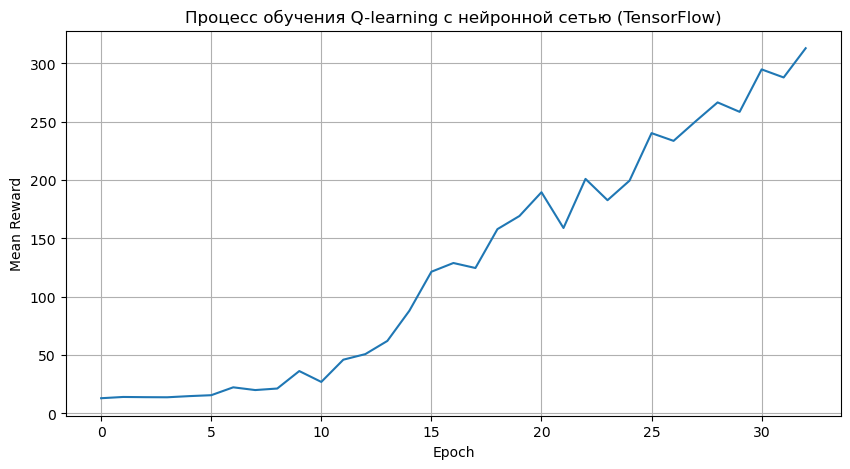

In [13]:
epsilon = 0.5
rewards_history = []

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    mean_reward = np.mean(session_rewards)
    rewards_history.append(mean_reward)
    
    print("epoch#{}\tmean reward={:.3f}\tepsilon={:.3f}".format(i, mean_reward, epsilon))
    
    epsilon *= 0.99
    assert epsilon >= 1e-4, "Убедитесь, что эпсилон всегда отличен от нуля во время обучения"
    
    if mean_reward > 300:
        print("You Win!")
        break

# Визуализация процесса обучения
plt.figure(figsize=(10, 5))
plt.plot(rewards_history)
plt.xlabel('Epoch')
plt.ylabel('Mean Reward')
plt.title('Процесс обучения Q-learning с нейронной сетью (TensorFlow)')
plt.grid(True)
plt.show()

In [14]:
pip install torch==2.0.0 torchvision==0.15.0 torchaudio==2.0.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118Note: you may need to restart the kernel to use updated packages.



In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [36]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim[0], 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, n_actions)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # Линейная активация для Q-значений
        return x

# Инициализация сети
state_dim = env.observation_space.shape
n_actions = env.action_space.n
q_network = QNetwork(state_dim, n_actions).to(device)
optimizer = optim.Adam(q_network.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

In [37]:
def get_action(state, epsilon=0):
    """
    Выбор действия с эпсилон-жадной политикой (PyTorch версия)
    С вероятностью p=epsilon выбрать случайное действие,
    иначе выбрать действие с наибольшим Q(s, a)
    """
    if np.random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = q_network(state_tensor)
            return q_values.argmax().item()

In [39]:
# Проверка архитектуры сети
test_state, _ = env.reset()
test_tensor = torch.FloatTensor(test_state).unsqueeze(0).to(device)
test_output = q_network(test_tensor)

assert test_output.shape == (1, n_actions), \
    "пожалуйста, убедитесь, что ваша модель отображает состояние s->[Q(s,a0),..., Q(s, a_last)]"

# Проверка эпсилон-жадных исследований
assert np.shape(get_action(test_state)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(test_state, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [40]:
gamma = 0.99
    
def generate_session(env, t_max=1000, epsilon=0, train=False):
    """
    Играть с env с приблизительным агентом Q-обучения (PyTorch версия)
    Структура аналогична TensorFlow версии - обучение происходит на каждом шаге
    """
    total_reward = 0
    s, _ = env.reset()
    
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        
        if train:
            # Ваш код: один шаг обучения (аналог sess.run(train_step, ...) в TensorFlow)
            # Подготовка тензоров
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            a_t = torch.LongTensor([a]).to(device)
            r_t = torch.FloatTensor([r]).to(device)
            done_t = torch.BoolTensor([done]).to(device)
            
            # Текущие Q-значения для выбранного действия
            q_sa = q_network(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
            
            # Следующие Q-значения (с no_grad для stop_gradient)
            if not done:
                with torch.no_grad():
                    next_s_t = torch.FloatTensor(next_s).unsqueeze(0).to(device)
                    next_q = q_network(next_s_t)
                    max_next_q = next_q.max(dim=1)[0]
                target = r_t + gamma * max_next_q
            else:
                target = r_t
            
            # Вычисление потерь и обновление весов
            loss = loss_fn(q_sa, target.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        total_reward += r
        s = next_s
        
        if done:
            break
    
    return total_reward

epoch #0	mean reward=13.890	epsilon=0.500
epoch #1	mean reward=14.970	epsilon=0.495
epoch #2	mean reward=13.260	epsilon=0.490
epoch #3	mean reward=14.060	epsilon=0.485
epoch #4	mean reward=14.200	epsilon=0.480
epoch #5	mean reward=15.840	epsilon=0.475
epoch #6	mean reward=21.410	epsilon=0.471
epoch #7	mean reward=29.460	epsilon=0.466
epoch #8	mean reward=39.700	epsilon=0.461
epoch #9	mean reward=40.970	epsilon=0.457
epoch #10	mean reward=47.890	epsilon=0.452
epoch #11	mean reward=53.340	epsilon=0.448
epoch #12	mean reward=58.060	epsilon=0.443
epoch #13	mean reward=83.510	epsilon=0.439
epoch #14	mean reward=118.640	epsilon=0.434
epoch #15	mean reward=132.270	epsilon=0.430
epoch #16	mean reward=150.870	epsilon=0.426
epoch #17	mean reward=160.820	epsilon=0.421
epoch #18	mean reward=176.760	epsilon=0.417
epoch #19	mean reward=186.650	epsilon=0.413
epoch #20	mean reward=165.490	epsilon=0.409
epoch #21	mean reward=244.130	epsilon=0.405
epoch #22	mean reward=181.170	epsilon=0.401
epoch #23	me

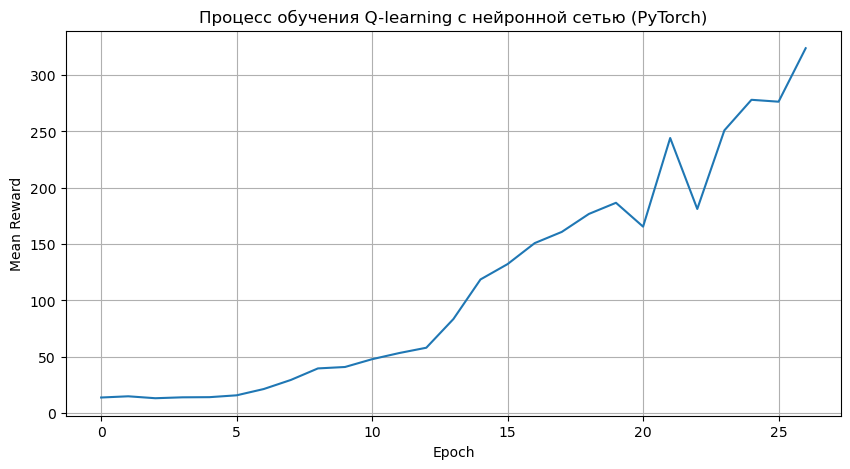

In [41]:
epsilon = 0.5
rewards_history_torch = []

for i in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    mean_reward = np.mean(session_rewards)
    rewards_history_torch.append(mean_reward)
    
    print("epoch #{}\tmean reward={:.3f}\tepsilon={:.3f}".format(i, mean_reward, epsilon))
    
    epsilon *= 0.99
    assert epsilon >= 1e-4, "Убедитесь, что эпсилон всегда отличен от нуля во время обучения"
    
    if mean_reward > 300:
        print("You Win!")
        break

# Визуализация процесса обучения
plt.figure(figsize=(10, 5))
plt.plot(rewards_history_torch)
plt.xlabel('Epoch')
plt.ylabel('Mean Reward')
plt.title('Процесс обучения Q-learning с нейронной сетью (PyTorch)')
plt.grid(True)
plt.show()